In [2]:
# PARTE A1
# PARTE A.1  División train/test y tabla de diferencia de medias
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy import stats

# en este paso fijo paths y cargo la base
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron_final.xlsx"
df = pd.read_excel(file_resp)

# en este paso verifico columnas obligatorias
if not {"pobre","anio"}.issubset(df.columns):
    raise KeyError("Faltan columnas obligatorias: pobre y/o anio")

# en este paso tipifico pobre y anio
df["pobre"] = pd.to_numeric(df["pobre"], errors="coerce")
df["anio"] = pd.to_numeric(df["anio"], errors="coerce")

# en este paso defino filtro para excluir todo lo ligado a ingreso
bloquear = {"ingreso", "itf", "itfipc", "itf_hogar", "ingreso_per_capita", "ingreso_necesario"}
def es_ingreso(col):
    c = str(col).lower()
    return any(tok in c for tok in bloquear)

# en este paso selecciono todas las variables elegibles excepto pobre, anio y las ligadas a ingreso
vars_X_base = [
    c for c in df.columns
    if c not in {"pobre", "anio"} and not es_ingreso(c)
]

# en este paso construyo X usando solo variables numéricas y mantengo nombres originales
def construir_X(subdf, cols):
    # en este paso filtro a numéricas
    X_num = subdf[cols].select_dtypes(include=[np.number]).apply(pd.to_numeric, errors="coerce")
    # en este paso agrego la constante para el intercepto
    X = X_num.copy()
    X.insert(0, "constante", 1.0)
    return X

# en este paso separo por año
resp_2005 = df[df["anio"] == 2005].copy()
resp_2025 = df[df["anio"] == 2025].copy()

# en este paso construyo matrices X e y por año
X2005 = construir_X(resp_2005, vars_X_base)
y2005 = resp_2005["pobre"].astype(float)

X2025 = construir_X(resp_2025, vars_X_base)
y2025 = resp_2025["pobre"].astype(float)

# en este paso divido 70/30 con semilla 444
Xtr05, Xte05, ytr05, yte05 = train_test_split(X2005, y2005, test_size=0.3, random_state=444)
Xtr25, Xte25, ytr25, yte25 = train_test_split(X2025, y2025, test_size=0.3, random_state=444)

print(f"2005 → train {Xtr05.shape[0]}  test {Xte05.shape[0]}")
print(f"2025 → train {Xtr25.shape[0]}  test {Xte25.shape[0]}")

# en este paso creo función de diferencia de medias con test t de Welch
def tabla_diff_medias(X_train, X_test, excluir=("constante",)):
    cols_eval = [c for c in X_train.columns if c not in excluir]
    filas = []
    for c in cols_eval:
        a = pd.to_numeric(X_train[c], errors="coerce").dropna()
        b = pd.to_numeric(X_test[c],  errors="coerce").dropna()
        if len(a)==0 or len(b)==0:
            continue
        tstat, pval = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        filas.append({
            "variable": c,
            "media_train": a.mean(),
            "media_test": b.mean(),
            "diferencia": a.mean() - b.mean(),
            "t_stat": tstat,
            "p_value": pval,
            "n_train": a.size,
            "n_test": b.size
        })
    out = pd.DataFrame(filas)
    return out.sort_values("p_value").reset_index(drop=True)

# en este paso calculo tablas por año
diff05 = tabla_diff_medias(Xtr05, Xte05)
diff25 = tabla_diff_medias(Xtr25, Xte25)

# en este paso exporto a Excel
out05 = PATH_BASES / "tabla_diff_medias_train_vs_test_2005.xlsx"
out25 = PATH_BASES / "tabla_diff_medias_train_vs_test_2025.xlsx"
with pd.ExcelWriter(out05, engine="openpyxl") as w:
    diff05.to_excel(w, index=False, sheet_name="diff_medias_2005")
with pd.ExcelWriter(out25, engine="openpyxl") as w:
    diff25.to_excel(w, index=False, sheet_name="diff_medias_2025")

# en este paso muestro top filas para control rápido
print("\nTop variables con mayor evidencia de diferencia 2005")
print(diff05.head(10).to_string(index=False))
print("\nTop variables con mayor evidencia de diferencia 2025")
print(diff25.head(10).to_string(index=False))



2005 → train 5588  test 2396
2025 → train 1836  test 787

Top variables con mayor evidencia de diferencia 2005
                 variable  media_train  media_test  diferencia    t_stat  p_value  n_train  n_test
                    edad2  1658.640122 1703.818030  -45.177908 -1.026395 0.304761     5588    2396
            estado_empleo     2.156110    2.181475   -0.025365 -0.921491 0.356843     5573    2386
               parentesco     2.046090    2.084795   -0.038705 -0.898095 0.369183     5576    2394
                     edad    34.546349   34.996661   -0.450312 -0.846061 0.397564     5588    2396
          nivel_ocupacion     4.232999    4.307596   -0.074597 -0.807828 0.419239     5588    2396
               n_personas     4.322119    4.292154    0.029965  0.709538 0.478027     5588    2396
     tipo_cobertura_salud     1.651038    1.642321    0.008717  0.669368 0.503296     5588    2396
    categoria_inactividad     1.618826    1.646912   -0.028085 -0.596231 0.551051     5588    239

In [3]:
# PARTE A.2 - Separar bases respondieron y norespondieron por año
import pandas as pd
from pathlib import Path

# en este paso cargo las bases
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron_final.xlsx"
file_noresp = PATH_BASES / "norespondieron.xlsx"

respondieron = pd.read_excel(file_resp)
norespondieron = pd.read_excel(file_noresp)

# en este paso tipifico el año
respondieron["anio"] = pd.to_numeric(respondieron["anio"], errors="coerce")
norespondieron["anio"] = pd.to_numeric(norespondieron["anio"], errors="coerce")

# en este paso creo los subconjuntos por año
respondieron_2005 = respondieron[respondieron["anio"] == 2005].copy()
respondieron_2025 = respondieron[respondieron["anio"] == 2025].copy()

norespondieron_2005 = norespondieron[norespondieron["anio"] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron["anio"] == 2025].copy()

# en este paso muestro el tamaño de cada subconjunto
print("respondieron_2005:", respondieron_2005.shape)
print("respondieron_2025:", respondieron_2025.shape)
print("norespondieron_2005:", norespondieron_2005.shape)
print("norespondieron_2025:", norespondieron_2025.shape)

# en este paso guardo las bases separadas
respondieron_2005.to_excel(PATH_BASES / "respondieron_2005.xlsx", index=False)
respondieron_2025.to_excel(PATH_BASES / "respondieron_2025.xlsx", index=False)
norespondieron_2005.to_excel(PATH_BASES / "norespondieron_2005.xlsx", index=False)
norespondieron_2025.to_excel(PATH_BASES / "norespondieron_2025.xlsx", index=False)

print("Listo, se generaron las 4 bases por año.")



respondieron_2005: (7984, 31)
respondieron_2025: (2623, 31)
norespondieron_2005: (12, 21)
norespondieron_2025: (534, 21)
Listo, se generaron las 4 bases por año.


---

# Modelo de Regresion Logistica

* 3) Estimacion y efectos Marginales


In [4]:
#Librerias a utilizar Punto B y D
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Estimación del modelo
logit_sm = sm.Logit(ytr25, Xtr25) #Logit con las variables de entrenamiento de 2025
res_logit = logit_sm.fit(disp=0)

# Tabla de resultados con coef, std err y odds-ratio
tabla_logit = pd.DataFrame({
    "Variable": Xtr25.columns,
    "Coeficiente": res_logit.params,
    "Error Std.": res_logit.bse,
    "p-valor": res_logit.pvalues,
})
tabla_logit["Odds Ratio"] = np.exp(tabla_logit["Coeficiente"])

display(tabla_logit.round(4))

# Exportar a Excel
tabla_logit.to_excel("resultados_logit_2025.xlsx", index=False)

#Predicciones
y_prob_logit = res_logit.predict(Xte25)

#desempeño
y_pred_logit = (y_prob_logit >= 0.5).astype(int)
print(classification_report(yte25, y_pred_logit))


C:\Users\War\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Variable,Coeficiente,Error Std.,p-valor,Odds Ratio
constante,constante,-5.5307,1.4974,0.0002,0.0040
Distincion_vivienda_hogar,Distincion_vivienda_hogar,-0.1204,0.4528,0.7903,0.8866
genero,genero,0.4514,0.2391,0.0591,1.5705
edad,edad,0.0746,0.0328,0.0228,1.0774
tipo_empleo,tipo_empleo,0.0995,0.0638,0.1185,1.1047
parentesco,parentesco,0.0950,0.0313,0.0024,1.0996
nivel_educ,nivel_educ,-0.0010,0.0537,0.9851,0.9990
estado_empleo,estado_empleo,0.0047,0.2247,0.9834,1.0047
categoria_inactividad,categoria_inactividad,0.3221,0.0838,0.0001,1.3800
tipo_cobertura_salud,tipo_cobertura_salud,-0.6088,0.2573,0.0180,0.5440


              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92       659
         1.0       0.64      0.23      0.34       128

    accuracy                           0.85       787
   macro avg       0.76      0.60      0.63       787
weighted avg       0.83      0.85      0.82       787



* 4) Visualización

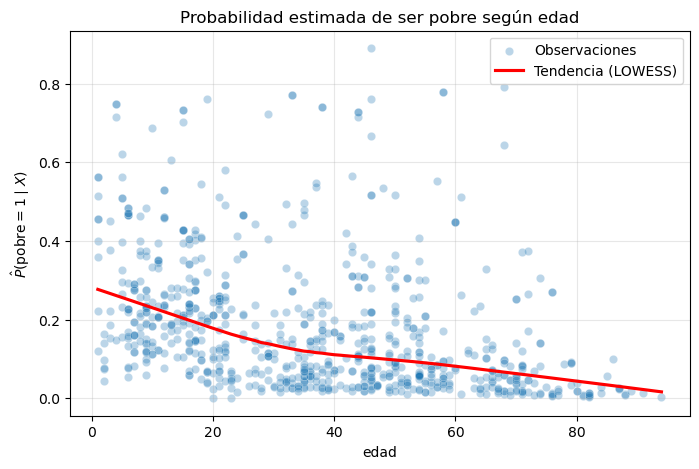

In [5]:
import seaborn as sns
# Selecciono una variable numérica relevante
var_num = "edad" if "edad" in Xte25.columns else "cantidad_miembros"

#  DataFrame con probabilidad predicha y la variable elegida
df_plot = pd.DataFrame({
    var_num: Xte25[var_num],
    "prob_pobre": y_prob_logit
})

# Gráfico el scatter mas la linea de tendencia
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_plot, x=var_num, y="prob_pobre", alpha=0.3, label="Observaciones")
sns.regplot(data=df_plot, x=var_num, y="prob_pobre",
            lowess=True, scatter=False, color="red", label="Tendencia (LOWESS)")
plt.title(f"Probabilidad estimada de ser pobre según {var_num}")
plt.xlabel(var_num)
plt.ylabel(r"$\hat{P}(\text{pobre}=1 \mid X)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


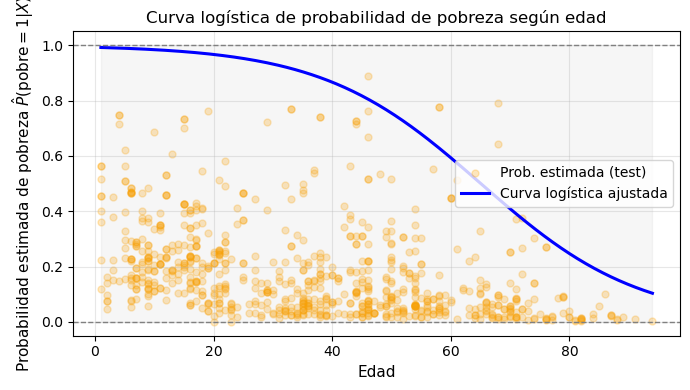

In [6]:
# --- Variable de interés ---
var_num = "edad"

# --- 1. Promedio de todas las variables de entrenamiento ---
mean_values = Xtr25.mean()

# --- 2. Rango continuo para la variable elegida ---
x_range = np.linspace(Xte25[var_num].min(), Xte25[var_num].max(), 200)

# --- 3. DataFrame auxiliar con todas las variables ---
X_aux = pd.DataFrame([mean_values] * len(x_range))
X_aux[var_num] = x_range
X_aux = X_aux[Xtr25.columns]

# --- 4. Predicciones logísticas (ajustadas con el modelo completo) ---
y_pred_curve = 1 - res_logit.predict(X_aux)

# Si el coeficiente de edad es negativo, dejamos así; si es positivo e invertido, podés hacer: y_pred_curve = 1 - y_pred_curve

# --- 5. Datos reales para el scatter ---
df_plot = pd.DataFrame({
    var_num: Xte25[var_num],
    "prob_pobre": y_prob_logit
}).dropna().sort_values(by=var_num)

# --- 6. Gráfico ---
plt.figure(figsize=(7, 4))
plt.scatter(df_plot[var_num], df_plot["prob_pobre"],
            alpha=0.25, color="orange", s=25, label="Prob. estimada (test)")

# Curva logística teórica
plt.plot(x_range, y_pred_curve, color="blue", linewidth=2.2, label="Curva logística ajustada")

# --- 7. Sombreado entre 0 y 1 ---
plt.fill_between(x_range, 0, 1, color="gray", alpha=0.07)

# --- 8. Líneas punteadas horizontales en 0 y 1 ---
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axhline(1, color="gray", linestyle="--", linewidth=1)

# --- 9. Estilo general ---
plt.ylim(-0.05, 1.05)
plt.xlabel("Edad", fontsize=11)
plt.ylabel(r"Probabilidad estimada de pobreza $\hat{P}(\text{pobre}=1|X)$", fontsize=11)
plt.title(f"Curva logística de probabilidad de pobreza según {var_num}", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



---

# Método de Vecinos Cercanos (KNN)


* 5) Estimación

In [7]:
#PARTE C.5

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Aseguro entrada numérica (si hay categóricas, paso a dummies)
Xtr25_knn = pd.get_dummies(Xtr25, drop_first=True)
Xte25_knn = pd.get_dummies(Xte25, drop_first=True)
# Alineo columnas entre train y test
Xte25_knn = Xte25_knn.reindex(columns=Xtr25_knn.columns, fill_value=0)

resultados_knn = {}

for k in [1, 5, 10]:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),  # no centra, útil con dummies dispersas
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(Xtr25_knn, ytr25)
    ypred = pipe.predict(Xte25_knn)
    resultados_knn[k] = {"modelo": pipe, "y_pred": ypred}

    print(f"\n=== KNN (K={k}) — desempeño en test 2025 ===")
    print(classification_report(yte25, ypred, digits=3))



=== KNN (K=1) — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.983     0.979     0.981       659
         1.0      0.893     0.914     0.903       128

    accuracy                          0.968       787
   macro avg      0.938     0.946     0.942       787
weighted avg      0.969     0.968     0.968       787


=== KNN (K=5) — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.911     0.958     0.933       659
         1.0      0.702     0.516     0.595       128

    accuracy                          0.886       787
   macro avg      0.806     0.737     0.764       787
weighted avg      0.877     0.886     0.878       787


=== KNN (K=10) — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.880     0.956     0.916       659
         1.0      0.592     0.328     0.422       128

    accuracy                          0.854      

* 6) Visualización

👉 Variables usadas para la frontera KNN: edad vs n_personas
💾 Guardado: frontera_knn_1_edad_vs_n_personas.png


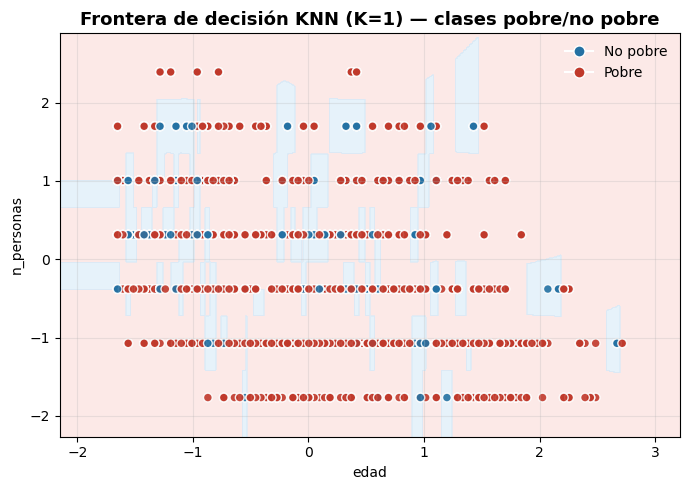

💾 Guardado: frontera_knn_10_edad_vs_n_personas.png


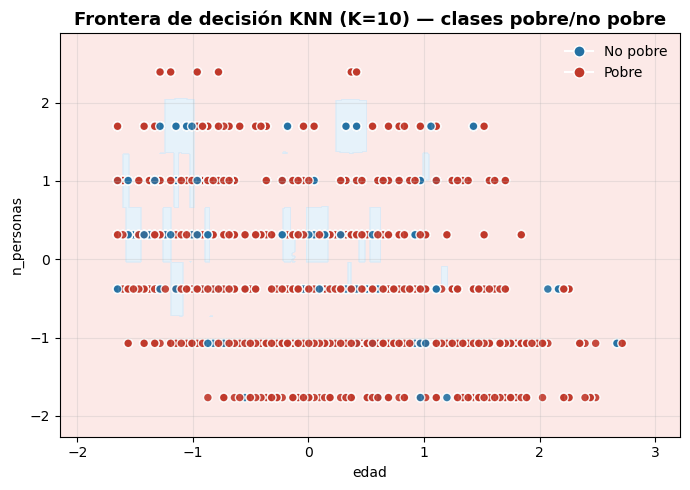

In [8]:
#PARTE C.6

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


#1) Tomo columnas numéricas disponibles en Xtr25 (evito dummies y 'constante')
num_cols_all = Xtr25.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c.lower() != "constante"]

# Lista de preferidas (en orden). Cambiá/extendé si querés.
preferidas = ["edad", "cantidad_miembros", "n_personas", "horastrab", "miembros", "tamano_hogar", "tamanio_hogar"]

candidatas = [c for c in preferidas if c in num_cols_all]

# Si no hay al menos 2 preferidas, completo con otras numéricas
resto = [c for c in num_cols_all if c not in candidatas]
vars_2d = (candidatas + resto)[:2]

if len(vars_2d) < 2:
    raise ValueError("No encontré al menos 2 variables numéricas en Xtr25 para graficar.")

f1, f2 = vars_2d
print(f"👉 Variables usadas para la frontera KNN: {f1} vs {f2}")

# 2) Construyo matriz 2D con imputación simple (mediana) y escalado
X_plot = Xtr25[[f1, f2]].copy()
# imputo faltantes con mediana para no romper
X_plot[f1] = pd.to_numeric(X_plot[f1], errors="coerce")
X_plot[f2] = pd.to_numeric(X_plot[f2], errors="coerce")
X_plot = X_plot.fillna(X_plot.median(numeric_only=True))

y_plot = ytr25.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_plot.values)

def plot_knn_frontier(k, save_png=False):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y_plot)

    # Malla
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Estilo lindo para informe
    light = ListedColormap(["#FADBD8", "#D6EAF8"])
    bold  = ListedColormap(["#C0392B", "#2471A3"])

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, cmap=light, alpha=0.6, levels=2)
    plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_plot, cmap=bold,
                edgecolor="white", s=40, alpha=0.9)
    plt.title(f"Frontera de decisión KNN (K={k}) — clases pobre/no pobre", fontsize=13, fontweight="bold")
    plt.xlabel(f1); plt.ylabel(f2)
    plt.grid(alpha=0.25)
    # leyenda manual
    plt.legend(handles=[
        plt.Line2D([0],[0], marker='o', color='w', label='No pobre',
                   markerfacecolor='#2471A3', markersize=8),
        plt.Line2D([0],[0], marker='o', color='w', label='Pobre',
                   markerfacecolor='#C0392B', markersize=8)
    ], loc='upper right', frameon=False)
    plt.tight_layout()

    if save_png:
        out = f"frontera_knn_{k}_{f1}_vs_{f2}.png"
        plt.savefig(out, dpi=300)
        print(f"💾 Guardado: {out}")
    plt.show()

# 3) Graficos solicitados por el TP: K=1 y K=10
plot_knn_frontier(1,  save_png=True)
plot_knn_frontier(10, save_png=True)

* 7) K optimo por Cross-validation


=== CV 5-fold — Accuracy por K ===


,K,accuracy_mean,accuracy_std
0,1,0.9276,0.0092
1,2,0.9118,0.0078
2,3,0.8889,0.0122
3,4,0.8595,0.0070
4,5,0.8464,0.0087
5,6,0.8410,0.0079
6,7,0.8426,0.0078
7,8,0.8284,0.0053
8,9,0.8268,0.0082
9,10,0.8268,0.0118



K óptimo (CV 5-fold, métrica accuracy): 1

=== KNN con K–CV — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.983     0.979     0.981       659
         1.0      0.893     0.914     0.903       128

    accuracy                          0.968       787
   macro avg      0.938     0.946     0.942       787
weighted avg      0.969     0.968     0.968       787



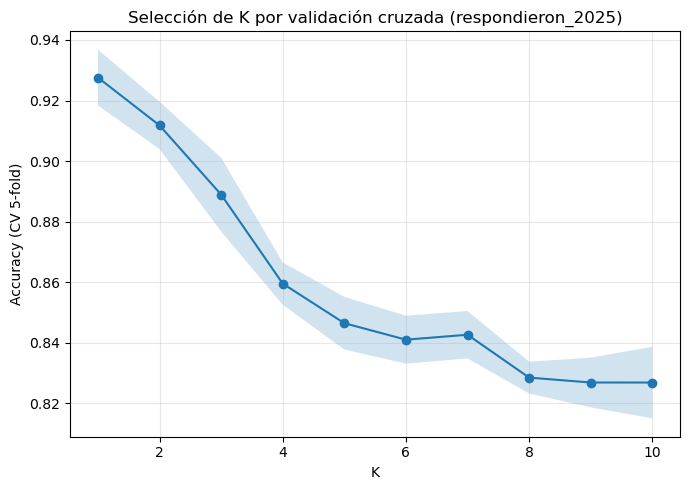

In [9]:
#PARTE C.7

from sklearn.model_selection import cross_val_score


# Reuso matrices del Ítem 5; si no existen, las genero al vuelo
if "Xtr25_knn" not in globals():
    Xtr25_knn = pd.get_dummies(Xtr25, drop_first=True)
    Xte25_knn = pd.get_dummies(Xte25, drop_first=True)
    Xte25_knn = Xte25_knn.reindex(columns=Xtr25_knn.columns, fill_value=0)

ks = list(range(1, 10+1))
acc_mean, acc_std = [], []

for k in ks:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, Xtr25_knn, ytr25, cv=5, scoring="accuracy", n_jobs=-1)
    acc_mean.append(scores.mean())
    acc_std.append(scores.std())

# Tabla de resultados CV
cv_df = pd.DataFrame({"K": ks, "accuracy_mean": acc_mean, "accuracy_std": acc_std})
print("\n=== CV 5-fold — Accuracy por K ===")
display(cv_df.round(4))

# Selección de K óptimo (máximo accuracy promedio)
k_opt = cv_df.loc[cv_df["accuracy_mean"].idxmax(), "K"]
print(f"\nK óptimo (CV 5-fold, métrica accuracy): {int(k_opt)}")

# Entreno el modelo final KNN con K–CV en todo Xtr25
pipe_kcv = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("knn", KNeighborsClassifier(n_neighbors=int(k_opt)))
])
pipe_kcv.fit(Xtr25_knn, ytr25)

# Desempeño del KNN K–CV en test 2025
y_pred_kcv_test = pipe_kcv.predict(Xte25_knn)
print("\n=== KNN con K–CV — desempeño en test 2025 ===")
print(classification_report(yte25, y_pred_kcv_test, digits=3))

# (Opcional) Visual rápido en pantalla (no se guarda)
plt.figure(figsize=(7,5))
plt.plot(cv_df["K"], cv_df["accuracy_mean"], marker="o")
plt.fill_between(cv_df["K"],
                 cv_df["accuracy_mean"] - cv_df["accuracy_std"],
                 cv_df["accuracy_mean"] + cv_df["accuracy_std"],
                 alpha=0.2)
plt.xlabel("K"); plt.ylabel("Accuracy (CV 5-fold)")
plt.title("Selección de K por validación cruzada (respondieron_2025)")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


# Modelo de Regresion Logistica con Regularización: Ridg y LASSO

* 8) Visualizacion

C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = 

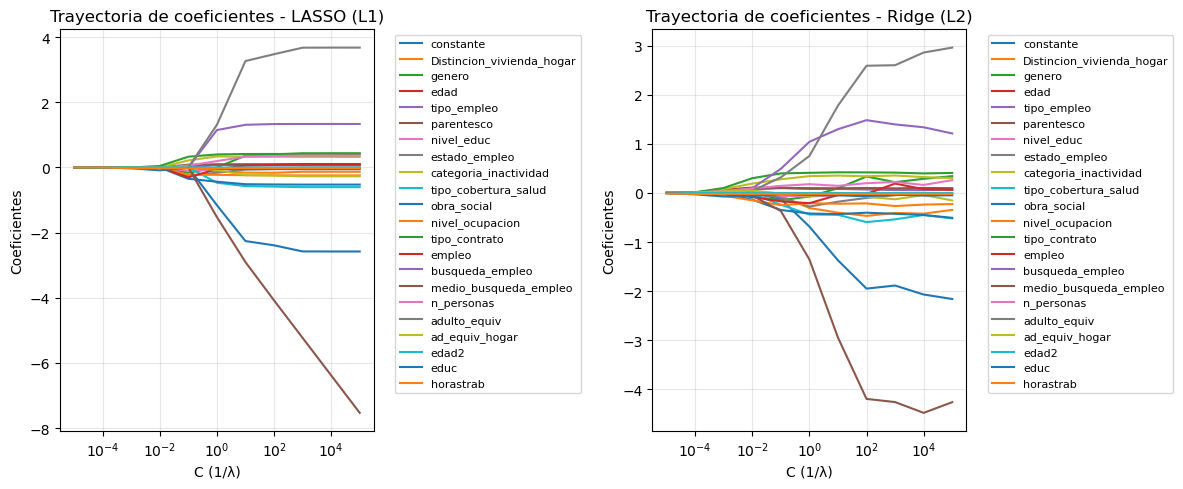

In [10]:
# Definimos grilla de penalización: C = 1/λ
C_grid = np.logspace(-5, 5, 11)  # 11 puntos entre 10^-5 y 10^5

#Guardamos en un array los coeficientes
coefs_lasso = []
coefs_ridge = []

# Entrenamos modelos para cada valor de C y guardamos los coeficientes
for C in C_grid:
    # LASSO
    lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C, random_state=444, max_iter=3000) #Ajustamos
    lasso.fit(Xtr25, ytr25) #entrenamos
    coefs_lasso.append(lasso.coef_.ravel()) # guardamos

    # RIDGE
    ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=C, random_state=444, max_iter=3000)#Ajustamos
    ridge.fit(Xtr25, ytr25)# entrenamos
    coefs_ridge.append(ridge.coef_.ravel()) # guardamos

# Los guardamos en el array que armamos en un principio
coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)


#Plot
plt.figure(figsize=(12,5))

# ---- LASSO ----
plt.subplot(1,2,1)
for i, var in enumerate(Xtr25.columns):
    plt.plot(C_grid, coefs_lasso[:, i], label=var)
plt.xscale('log')
plt.title("Trayectoria de coeficientes - LASSO (L1)")
plt.xlabel("C (1/λ)")
plt.ylabel("Coeficientes")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()

# ---- RIDGE ----
plt.subplot(1,2,2)
for i, var in enumerate(Xtr25.columns):
    plt.plot(C_grid, coefs_ridge[:, i], label=var)
plt.xscale('log')
plt.title("Trayectoria de coeficientes - Ridge (L2)")
plt.xlabel("C (1/λ)")
plt.ylabel("Coeficientes")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()

plt.show()

* 9) Penalidad Optima por Cross-Validation y Visualizacion

λ_opt LASSO (L1): 0.100000
λ_opt RIDGE (L2): 0.100000
C_opt LASSO: 10.000000
C_opt RIDGE: 10.000000


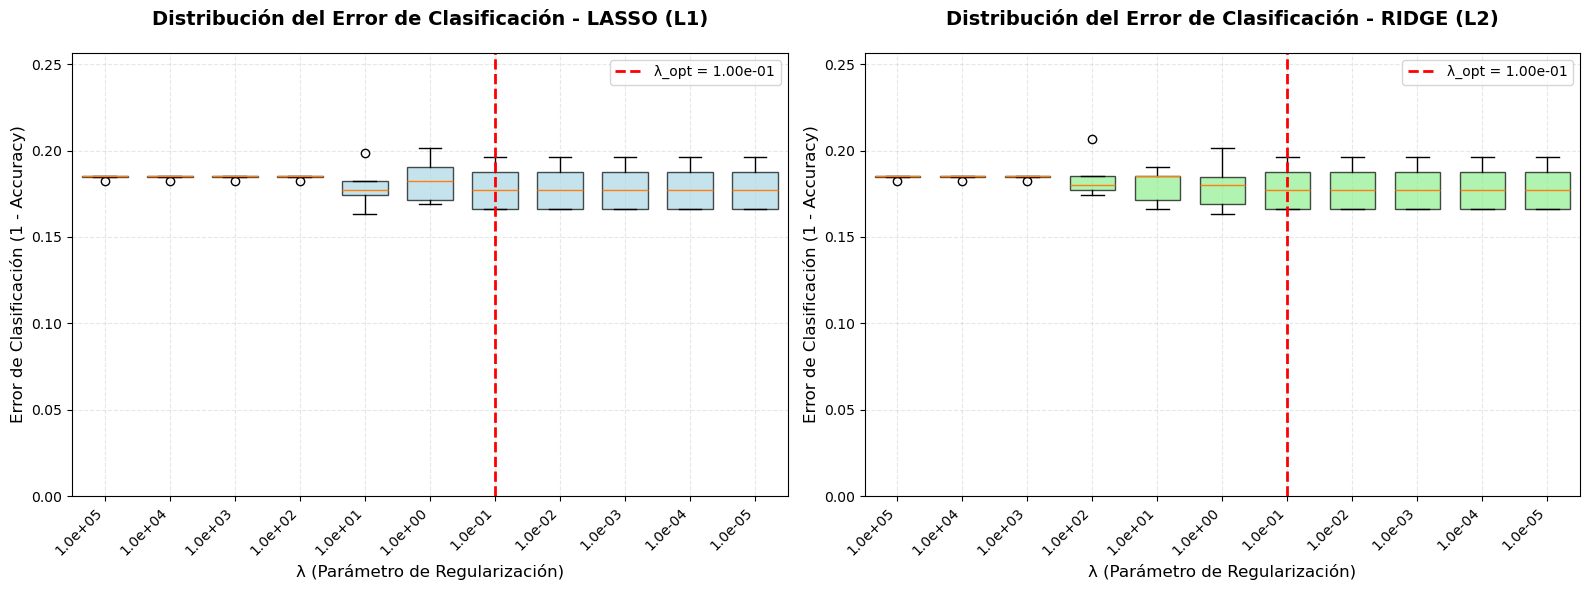

λ = 1.0e+05: Proporción media de vars ignoradas = 1.000
λ = 1.0e+04: Proporción media de vars ignoradas = 1.000
λ = 1.0e+03: Proporción media de vars ignoradas = 1.000
λ = 1.0e+02: Proporción media de vars ignoradas = 0.818
λ = 1.0e+01: Proporción media de vars ignoradas = 0.364
λ = 1.0e+00: Proporción media de vars ignoradas = 0.045
λ = 1.0e-01: Proporción media de vars ignoradas = 0.091
λ = 1.0e-02: Proporción media de vars ignoradas = 0.045
λ = 1.0e-03: Proporción media de vars ignoradas = 0.045
λ = 1.0e-04: Proporción media de vars ignoradas = 0.045
λ = 1.0e-05: Proporción media de vars ignoradas = 0.045


C:\Users\War\AppData\Local\Temp\ipykernel_9804\2274659573.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


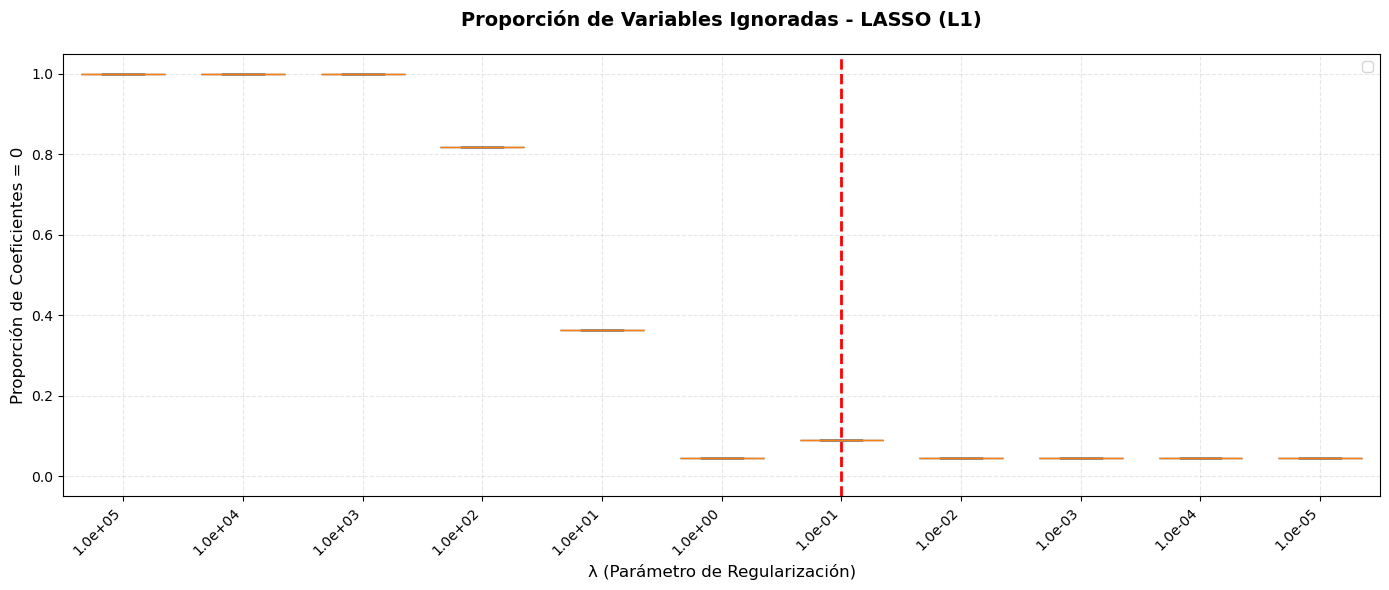

In [11]:
# Configuramos la penalización
C_grid = np.logspace(-5, 5, 11)
lambda_grid = 1 / C_grid

#Estrandarizamos datos
scaler = StandardScaler()
Xtr25_scaled = scaler.fit_transform(Xtr25)

#ENTRENAMIENTO CON LOGISTIC REGRESSION CV (5-FOLD)

# Modelo LASSO (L1)
lasso_cv = LogisticRegressionCV(Cs=C_grid, cv=5, penalty='l1', solver='liblinear', random_state=444, max_iter=5000, scoring='accuracy', n_jobs=-1)
lasso_cv.fit(Xtr25_scaled, ytr25)

# Modelo RIDGE (L2)
ridge_cv = LogisticRegressionCV(Cs=C_grid, cv=5, penalty='l2', solver='lbfgs', random_state=444, max_iter=5000, scoring='accuracy', n_jobs=-1)
ridge_cv.fit(Xtr25_scaled, ytr25)

#RESULTADOS DE λ ÓPTIMO
lambda_opt_lasso = 1 / lasso_cv.C_[0]
lambda_opt_ridge = 1 / ridge_cv.C_[0]

print(f"λ_opt LASSO (L1): {lambda_opt_lasso:.6f}")
print(f"λ_opt RIDGE (L2): {lambda_opt_ridge:.6f}")
print(f"C_opt LASSO: {lasso_cv.C_[0]:.6f}")
print(f"C_opt RIDGE: {ridge_cv.C_[0]:.6f}")

# 4. BOX-PLOTS DEL ERROR DE CLASIFICACIÓN

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Preparar datos para boxplots
error_lasso = 1 - lasso_cv.scores_[1]  # Error = 1 - Accuracy
error_ridge = 1 - ridge_cv.scores_[1]
positions = range(1, len(C_grid) + 1)
labels = [f'{lam:.1e}' for lam in lambda_grid]

#print(error_lasso)
#print(error_ridge)

# BOX-PLOT LASSO
box_lasso = ax1.boxplot([error_lasso[:, i] for i in range(len(C_grid))],
                       positions=positions, widths=0.7, patch_artist=True)
for patch in box_lasso['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax1.set_title('Distribución del Error de Clasificación - LASSO (L1)',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('λ (Parámetro de Regularización)', fontsize=12)
ax1.set_ylabel('Error de Clasificación (1 - Accuracy)', fontsize=12)
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
opt_idx_lasso = np.argmin(np.abs(lambda_grid - lambda_opt_lasso))
ax1.axvline(x=positions[opt_idx_lasso], color='red', linestyle='--', linewidth=2,
           label=f'λ_opt = {lambda_opt_lasso:.2e}')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0, max(error_lasso.max(), error_ridge.max()) + 0.05])

# BOX-PLOT RIDGE
box_ridge = ax2.boxplot([error_ridge[:, i] for i in range(len(C_grid))],
                       positions=positions, widths=0.7, patch_artist=True)
for patch in box_ridge['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)
ax2.set_title('Distribución del Error de Clasificación - RIDGE (L2)',
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('λ (Parámetro de Regularización)', fontsize=12)
ax2.set_ylabel('Error de Clasificación (1 - Accuracy)', fontsize=12)
ax2.set_xticks(positions)
ax2.set_xticklabels(labels, rotation=45, ha='right')
opt_idx_ridge = np.argmin(np.abs(lambda_grid - lambda_opt_ridge))
ax2.axvline(x=positions[opt_idx_ridge], color='red', linestyle='--', linewidth=2,
           label=f'λ_opt = {lambda_opt_ridge:.2e}')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0, max(error_lasso.max(), error_ridge.max()) + 0.05])

plt.tight_layout()
plt.show()

# BOX-PLOT OPCIONAL: PROPORCIÓN DE VARIABLES IGNORADAS (LASSO)
# Para mayor robustez, calcular sobre múltiples random states
random_states = [444, 445, 446, 447, 448]
prop_ceros_por_lambda = []

for i, C in enumerate(C_grid):
    prop_ceros_folds = []
    for rs in random_states:
        model = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=C,
            random_state=rs,
            max_iter=5000
        )
        model.fit(Xtr25_scaled, ytr25)
        # Calcular proporción de coeficientes iguales a cero
        prop_cero = np.mean(model.coef_.ravel() == 0)
        prop_ceros_folds.append(prop_cero)

    prop_ceros_por_lambda.append(prop_ceros_folds)
    print(f"λ = {lambda_grid[i]:.1e}: Proporción media de vars ignoradas = {np.mean(prop_ceros_folds):.3f}")

# Gráfico de variables ignoradas
plt.figure(figsize=(14, 6))
box_ignoradas = plt.boxplot(prop_ceros_por_lambda, positions=positions, widths=0.7, patch_artist=True)

# Colorear cajas
for patch in box_ignoradas['boxes']:
    patch.set_facecolor('salmon')
    patch.set_alpha(0.7)
plt.title('Proporción de Variables Ignoradas - LASSO (L1)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('λ (Parámetro de Regularización)', fontsize=12)
plt.ylabel('Proporción de Coeficientes = 0', fontsize=12)
plt.xticks(positions, labels, rotation=45, ha='right')
plt.axvline(x=positions[opt_idx_lasso], color='red', linestyle='--', linewidth=2,
           )
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

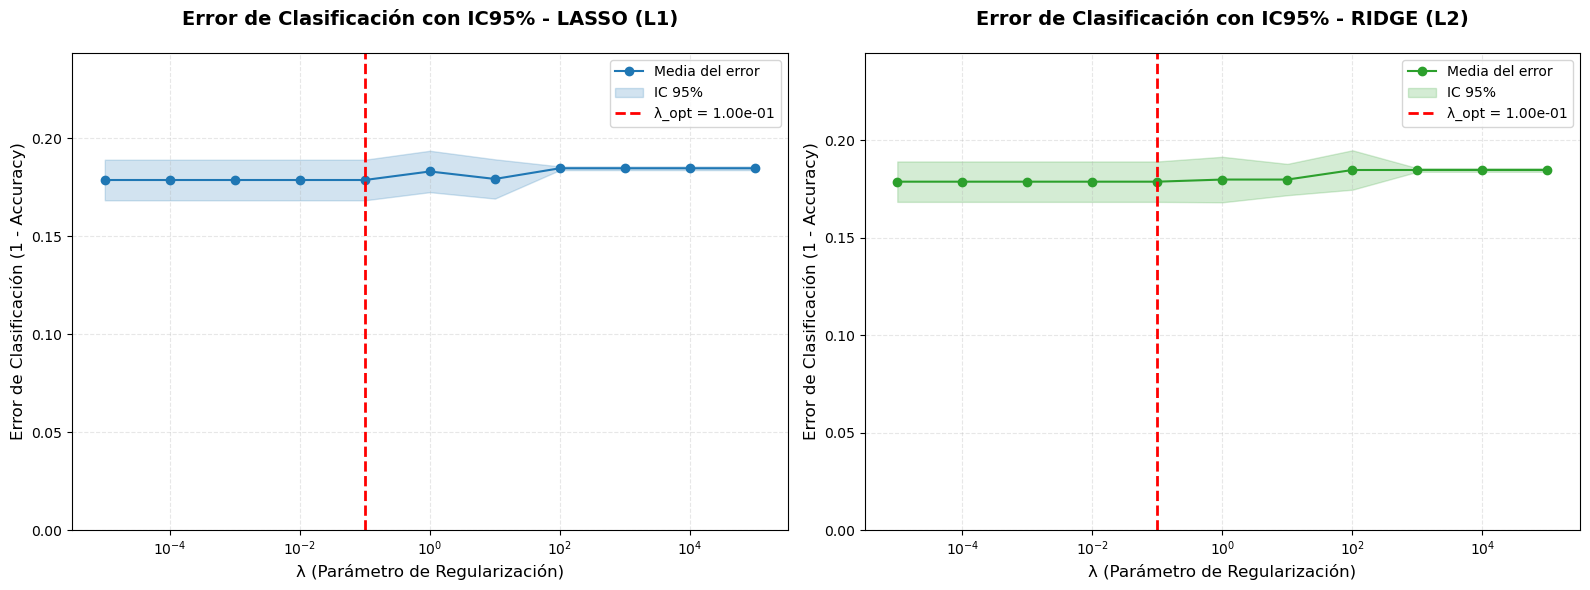

In [12]:
# --- INTERVALOS DE CONFIANZA DEL ERROR DE CLASIFICACIÓN ---

import scipy.stats as st

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

positions = np.arange(len(lambda_grid))
labels = [f'{lam:.1e}' for lam in lambda_grid]

def plot_ci(ax, errores, lambda_grid, color, titulo, lambda_opt):
    medias = errores.mean(axis=0)
    ses = errores.std(axis=0) / np.sqrt(errores.shape[0])  # Error estándar
    ci_inf = medias - 1.96 * ses
    ci_sup = medias + 1.96 * ses

    ax.plot(lambda_grid, medias, marker='o', color=color, label='Media del error')
    ax.fill_between(lambda_grid, ci_inf, ci_sup, color=color, alpha=0.2, label='IC 95%')

    ax.axvline(x=lambda_opt, color='red', linestyle='--', linewidth=2,
               label=f'λ_opt = {lambda_opt:.2e}')
    ax.set_xscale('log')
    ax.set_xlabel('λ (Parámetro de Regularización)', fontsize=12)
    ax.set_ylabel('Error de Clasificación (1 - Accuracy)', fontsize=12)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10)
    ax.set_ylim([0, max(ci_sup) + 0.05])

# Gráfico LASSO
plot_ci(ax1, error_lasso, lambda_grid, 'tab:blue',
        'Error de Clasificación con IC95% - LASSO (L1)', lambda_opt_lasso)

# Gráfico RIDGE
plot_ci(ax2, error_ridge, lambda_grid, 'tab:green',
        'Error de Clasificación con IC95% - RIDGE (L2)', lambda_opt_ridge)

plt.tight_layout()
plt.show()


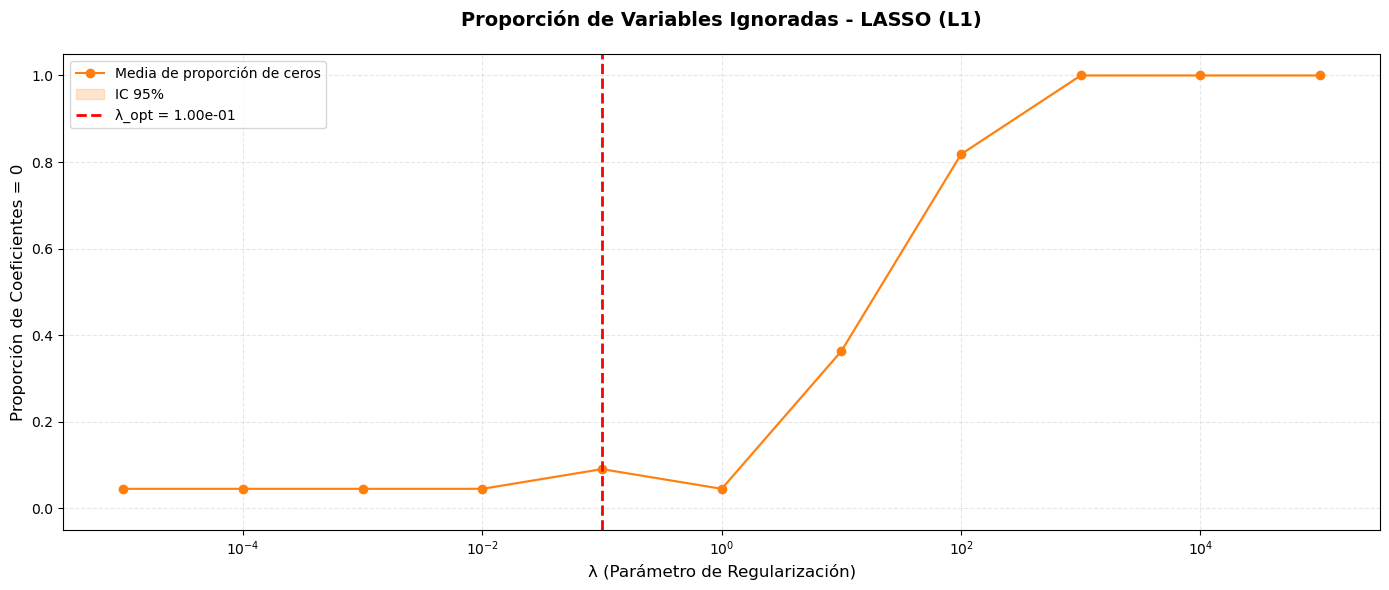

In [13]:
# --- INTERVALO DE CONFIANZA: PROPORCIÓN DE VARIABLES IGNORADAS (LASSO) ---

import scipy.stats as st

plt.figure(figsize=(14, 6))

# Calcular media y IC95% para cada λ
prop_ceros_por_lambda = np.array(prop_ceros_por_lambda)
medias = prop_ceros_por_lambda.mean(axis=1)
ses = prop_ceros_por_lambda.std(axis=1, ddof=1) / np.sqrt(prop_ceros_por_lambda.shape[1])
ci_inf = medias - 1.96 * ses
ci_sup = medias + 1.96 * ses

# Graficar
plt.plot(lambda_grid, medias, color='tab:orange', marker='o', label='Media de proporción de ceros')
plt.fill_between(lambda_grid, ci_inf, ci_sup, color='tab:orange', alpha=0.2, label='IC 95%')

plt.axvline(x=lambda_opt_lasso, color='red', linestyle='--', linewidth=2,
            label=f'λ_opt = {lambda_opt_lasso:.2e}')

plt.title('Proporción de Variables Ignoradas - LASSO (L1)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('λ (Parámetro de Regularización)', fontsize=12)
plt.ylabel('Proporción de Coeficientes = 0', fontsize=12)
plt.xscale('log')
plt.ylim([-0.05, 1.05])
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


* 10) Comparacion de coeficientes

In [14]:
# Recuperamos los valores óptimos de C
C_opt_lasso = lasso_cv.C_[0]
C_opt_ridge = ridge_cv.C_[0]

# Modelo sin penalidad
logit_simple = LogisticRegression(penalty=None, solver='lbfgs', max_iter=3000)
logit_simple.fit(Xtr25, ytr25)

# Modelo LASSO con penalidad óptima
logit_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C_opt_lasso, max_iter=3000)
logit_lasso.fit(Xtr25, ytr25)

# Modelo Ridge con penalidad óptima
logit_ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=C_opt_ridge, max_iter=3000)
logit_ridge.fit(Xtr25, ytr25)

# Tabla comparativa
coef_df = pd.DataFrame({
    "Variable": Xtr25.columns,
    "Sin penalidad": logit_simple.coef_.ravel(),
    "LASSO (λ^cv)": logit_lasso.coef_.ravel(),
    "Ridge (λ^cv)": logit_ridge.coef_.ravel()
})

# Guardar tabla
coef_df.to_excel("coeficientes_logit_comparacion_2025.xlsx", index=False)

# Mostrar primeras filas
display(coef_df.head(10))


C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = 

,Variable,Sin penalidad,LASSO (λ^cv),Ridge (λ^cv)
0,constante,-2.127174,-1.930983,-1.372620
1,Distincion_vivienda_hogar,-0.432460,-0.159484,-0.400890
2,genero,0.301887,0.362442,0.095094
3,edad,0.086226,0.069513,0.084806
4,tipo_empleo,0.079410,0.090619,0.082338
5,parentesco,0.096471,0.095854,0.093099
6,nivel_educ,-0.018788,-0.018446,-0.047899
7,estado_empleo,-0.032905,-0.075926,-0.177584
8,categoria_inactividad,0.348395,0.332853,0.353935
9,tipo_cobertura_salud,-0.680911,-0.566559,-0.445631


# Bonus : Elastic Net

In [15]:
# Definir rango de C (inverso de lambda) y ratios L1
C_grid = np.logspace(-3, 2, 20)  # Ejemplo: de 0.001 a 100
l1_ratios = np.linspace(0.1, 0.9, 5)  # De 10% a 90% L1

# Entrenamiento
elastic_cv = LogisticRegressionCV(Cs=C_grid,cv=5,penalty='elasticnet',solver='saga',l1_ratios=l1_ratios,random_state=444,max_iter=3000,scoring='accuracy')
elastic_cv.fit(Xtr25, ytr25)

print(f"C óptimo Elastic Net: {elastic_cv.C_[0]:.4f}")
print(f"Ratio L1 óptimo: {elastic_cv.l1_ratio_[0]:.2f}")

# Tabla
coef_elastic = pd.DataFrame({
    "Variable": Xtr25.columns,
    "Coef_ElasticNet": elastic_cv.coef_.ravel()
})
display(coef_elastic.head(10))

C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached 

C óptimo Elastic Net: 0.0010
Ratio L1 óptimo: 0.10


,Variable,Coef_ElasticNet
0,constante,0.000000
1,Distincion_vivienda_hogar,0.000000
2,genero,0.000000
3,edad,-0.010629
4,tipo_empleo,-0.006129
5,parentesco,0.000000
6,nivel_educ,-0.007550
7,estado_empleo,0.000000
8,categoria_inactividad,0.000000
9,tipo_cobertura_salud,0.000000


C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


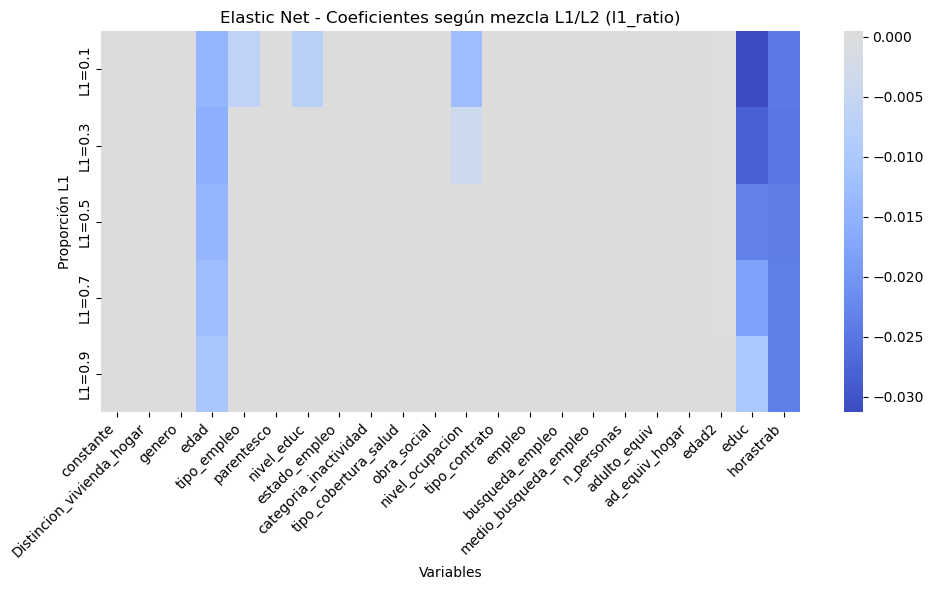

In [16]:
l1_ratios = np.linspace(0.1, 0.9, 5)
coefs_elastic = []

for ratio in l1_ratios:
    model = LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=ratio, C=elastic_cv.C_[0],
        random_state=444, max_iter=3000
    )
    model.fit(Xtr25, ytr25)
    coefs_elastic.append(model.coef_.ravel())

coefs_elastic = pd.DataFrame(coefs_elastic, columns=Xtr25.columns, index=[f"L1={r:.1f}" for r in l1_ratios])

plt.figure(figsize=(10,6))
sns.heatmap(coefs_elastic, cmap="coolwarm", center=0, annot=False)
plt.title("Elastic Net - Coeficientes según mezcla L1/L2 (l1_ratio)")
plt.xlabel("Variables")
plt.ylabel("Proporción L1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


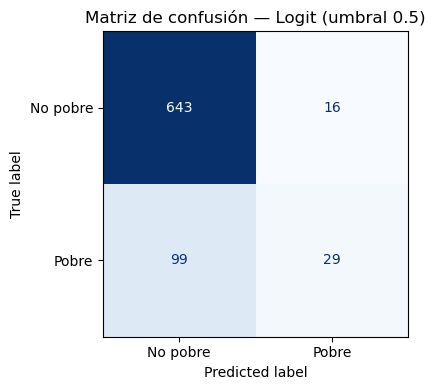

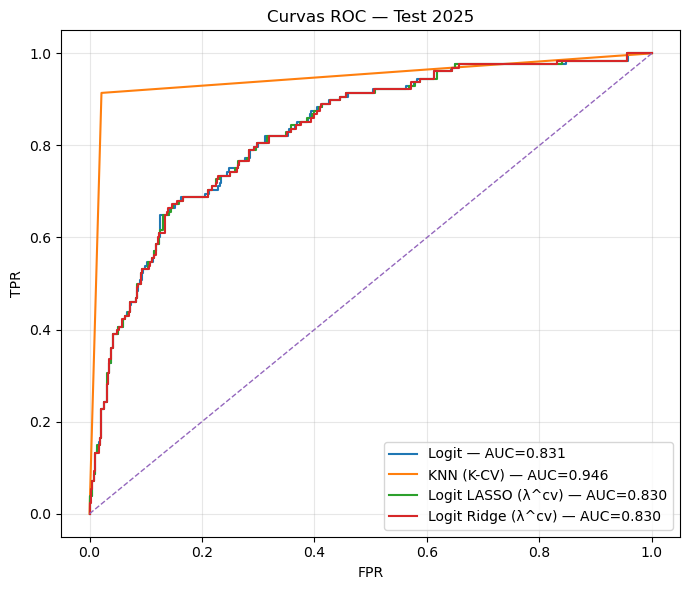


 Métricas en TEST 2025 (umbral 0.5)


,Accuracy,F1
Modelo,,
Logit,0.854,0.335
KNN (K-CV),0.968,0.903
Logit LASSO (λ^cv),0.854,0.335
Logit Ridge (λ^cv),0.854,0.335


In [17]:
# === PARTE E — Desempeño fuera de muestra (X_test 2025) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, accuracy_score
)

# --- 0) Chequeos mínimos de existencia ---
req = ["Xtr25","Xte25","ytr25","yte25","res_logit","pipe_kcv","lasso_cv","ridge_cv","scaler"]
faltan = [v for v in req if v not in globals()]
if faltan:
    raise RuntimeError(f"Faltan en memoria: {faltan}. Ejecutá antes las Partes B–D.")

# --- 1) Probabilidades / scores en TEST para cada modelo ---
# 1a) Logit (statsmodels) ya entrenado en Parte B
y_prob_logit = res_logit.predict(Xte25)  # vector de probabilidades en test

# 1b) KNN con K seleccionado por CV (Parte C.7)
#     Usa matrices con dummies si ya las tenés, si no las arma y alinea columnas
if "Xtr25_knn" not in globals() or "Xte25_knn" not in globals():
    Xtr25_knn = pd.get_dummies(Xtr25, drop_first=True)
    Xte25_knn = pd.get_dummies(Xte25, drop_first=True)
    Xte25_knn = Xte25_knn.reindex(columns=Xtr25_knn.columns, fill_value=0)
y_prob_knn = pipe_kcv.predict_proba(Xte25_knn)[:,1]

# 1c) Logit LASSO y 1d) Ridge con λ^cv (Parte D.9)
#     Esos modelos se entrenaron sobre Xtr25 escalado; escalo Xte25 con el MISMO scaler
Xte25_scaled = scaler.transform(Xte25)
y_prob_lasso = lasso_cv.predict_proba(Xte25_scaled)[:,1]
y_prob_ridge = ridge_cv.predict_proba(Xte25_scaled)[:,1]

#2) Matriz de confusión del logit con umbral 0.5
y_pred_logit_05 = (y_prob_logit >= 0.5).astype(int)
cm = confusion_matrix(yte25, y_pred_logit_05, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No pobre","Pobre"])
fig_cm = plt.figure(figsize=(4.5,4))
disp.plot(values_format="d", cmap="Blues", ax=plt.gca(), colorbar=False)
plt.title("Matriz de confusión — Logit (umbral 0.5)")
plt.tight_layout()
plt.savefig("E_matriz_confusion_logit_umbral05.png", dpi=300)
plt.show()

# 3) Curvas ROC para los cuatro modelos
def roc_xy(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc(fpr, tpr)

roc_logit  = roc_xy(yte25, y_prob_logit)
roc_knn    = roc_xy(yte25, y_prob_knn)
roc_lasso  = roc_xy(yte25, y_prob_lasso)
roc_ridge  = roc_xy(yte25, y_prob_ridge)

plt.figure(figsize=(7,6))
for (fpr, tpr, aucv), label in [
    (roc_logit, "Logit"),
    (roc_knn, "KNN (K-CV)"),
    (roc_lasso, "Logit LASSO (λ^cv)"),
    (roc_ridge, "Logit Ridge (λ^cv)")
]:
    plt.plot(fpr, tpr, label=f"{label} — AUC={aucv:.3f}")
plt.plot([0,1],[0,1], linestyle="--", linewidth=1)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Curvas ROC — Test 2025")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("E_curvas_ROC_test2025.png", dpi=300)
plt.show()

# 4) Tabla con 2 métricas: Accuracy y F1 (umbral 0.5)
def metrics_bin(y_true, y_score, thresh=0.5):
    y_pred = (y_score >= thresh).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

tabla = pd.DataFrame([
    {"Modelo":"Logit", **metrics_bin(yte25, y_prob_logit)},
    {"Modelo":"KNN (K-CV)", **metrics_bin(yte25, y_prob_knn)},
    {"Modelo":"Logit LASSO (λ^cv)", **metrics_bin(yte25, y_prob_lasso)},
    {"Modelo":"Logit Ridge (λ^cv)", **metrics_bin(yte25, y_prob_ridge)},
]).set_index("Modelo").round(3)

print("\n Métricas en TEST 2025 (umbral 0.5)")
display(tabla)

# Guardar a CSV para el informe
tabla.to_csv("E_metricas_modelos_test2025.csv", encoding="utf-8-sig")


In [18]:
# Predicción norespondieron_2025 con columnas del scaler e imputación segura
import numpy as np
import pandas as pd
from pathlib import Path

# Requisitos previos en memoria: scaler (fit en Xtr25) y lasso_cv (fit con Xtr25_scaled)
req = [v for v in ["scaler","lasso_cv"] if v not in globals()]
if req:
    raise RuntimeError(f"Faltan en memoria: {req}. Ejecutá la Parte D.9 antes.")

PATH = Path.cwd()
# Cargo norespondieron_2025; si no existe, lo genero desde norespondieron.xlsx
file_noresp_2025 = PATH / "norespondieron_2025.xlsx"
if not file_noresp_2025.exists():
    df_no = pd.read_excel(PATH / "norespondieron.xlsx")
    df_no["anio"] = pd.to_numeric(df_no.get("anio"), errors="coerce")
    df_no = df_no[df_no["anio"] == 2025].copy()
    df_no.to_excel(file_noresp_2025, index=False)

base = pd.read_excel(file_noresp_2025)

# Columnas esperadas por el scaler (orden exacto) y sus medias
cols_exp = list(getattr(scaler, "feature_names_in_", []))
if not cols_exp:
    raise RuntimeError("El scaler no tiene feature_names_in_. Volvé a fittear el scaler en Xtr25.")

means = pd.Series(scaler.mean_, index=cols_exp)

# Armo X_noresp con el mismo orden y SIN NaN
X_noresp = pd.DataFrame(index=base.index)
for c in cols_exp:
    if c in base.columns:
        s = pd.to_numeric(base[c], errors="coerce")
    elif c.lower() == "constante":
        s = pd.Series(1.0, index=base.index)
    else:
        s = pd.Series(np.nan, index=base.index)
    # imputo faltantes con la media del train usada por el scaler
    m = means.get(c, 0.0)
    s = s.fillna(m)
    X_noresp[c] = s

# Limpieza final
X_noresp = X_noresp.replace([np.inf, -np.inf], np.nan).fillna(means)

# Transformo y predigo
X_noresp_scaled = scaler.transform(X_noresp)
probs = lasso_cv.predict_proba(X_noresp_scaled)[:, 1]
preds = (probs >= 0.5).astype(int)

# Proporción de pobres predichos
n = len(preds)
k = int(preds.sum())
prop = k / n if n else np.nan
print(f"Personas no respondieron 2025: {n}")
print(f"Predichas pobres: {k} ({prop:.2%})")

# Exporto resultados
out = base.copy()
out["prob_pobre"] = probs
out["pobre_predicho"] = preds
out.to_excel("norespondieron_2025_predicciones.xlsx", index=False)
print("Archivo guardado: norespondieron_2025_predicciones.xlsx")


Personas no respondieron 2025: 534
Predichas pobres: 78 (14.61%)
Archivo guardado: norespondieron_2025_predicciones.xlsx
